In [1]:
import pandas as pd
%matplotlib inline

In [2]:
ava = pd.read_csv('./data/AviationData.csv', sep=',', encoding='latin')

C:\Users\EJacinto\AppData\Local\Temp\ipykernel_4816\3152766477.py:1: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  ava = pd.read_csv('./data/AviationData.csv', sep=',', encoding='latin')


In [3]:
pd.set_option('display.max_columns', None)
ava.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Schedule,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,NC6404,Stinson,108-3,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,Fatal(4),Destroyed,NaN,N5069P,Piper,PA24-180,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,Fatal(3),Destroyed,NaN,N5142R,Cessna,172M,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,N1168J,Rockwell,112,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,Fatal(1),Destroyed,NaN,N15NY,Cessna,501,No,NaN,NaN,NaN,NaN,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [4]:
avac = ava

In [5]:
avac = avac.drop(['Investigation.Type','Latitude','Longitude','Injury.Severity','Airport.Code','Airport.Name','Registration.Number','FAR.Description','Schedule','Report.Status','Publication.Date','Air.carrier'], axis=1)

In [6]:
avac.head()

,Event.Id,Accident.Number,Event.Date,Location,Country,Aircraft.damage,Aircraft.Category,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight
0,20001218X45444,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,Destroyed,NaN,Stinson,108-3,No,1.0,Reciprocating,Personal,2.0,0.0,0.0,0.0,UNK,Cruise
1,20001218X45447,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,Destroyed,NaN,Piper,PA24-180,No,1.0,Reciprocating,Personal,4.0,0.0,0.0,0.0,UNK,Unknown
2,20061025X01555,NYC07LA005,1974-08-30,"Saltville, VA",United States,Destroyed,NaN,Cessna,172M,No,1.0,Reciprocating,Personal,3.0,NaN,NaN,NaN,IMC,Cruise
3,20001218X45448,LAX96LA321,1977-06-19,"EUREKA, CA",United States,Destroyed,NaN,Rockwell,112,No,1.0,Reciprocating,Personal,2.0,0.0,0.0,0.0,IMC,Cruise
4,20041105X01764,CHI79FA064,1979-08-02,"Canton, OH",United States,Destroyed,NaN,Cessna,501,No,NaN,NaN,Personal,1.0,2.0,NaN,0.0,VMC,Approach


In [7]:
avac = avac.dropna(subset = ['Aircraft.damage'])

In [8]:
avac = avac[avac['Event.Date'].str[:4].astype(int) >= 1982]

In [9]:
avac = avac.drop_duplicates()

In [10]:
avac['Total.Minor.Injuries'] = avac['Total.Minor.Injuries'].fillna(0).astype(int)
avac['Total.Serious.Injuries'] = avac['Total.Serious.Injuries'].fillna(0).astype(int)
avac['Total.Fatal.Injuries'] = avac['Total.Fatal.Injuries'].fillna(0).astype(int)
avac['Total.Uninjured'] = avac['Total.Uninjured'].fillna(0).astype(int)

In [11]:
def total_injuries(row):
    return ((row['Total.Fatal.Injuries']) + (row['Total.Serious.Injuries']) + (row['Total.Minor.Injuries']))

avac['Total.Injuries'] = avac.apply(total_injuries, axis=1)

In [12]:
def fatality_rate(row):
    if row['Total.Injuries'] == 0:
        return 0
    else:
        return ((row['Total.Fatal.Injuries'] / row['Total.Injuries']) * 100)

avac['Fatality.Rate'] = avac.apply(fatality_rate, axis=1)

In [13]:
dm_count = ava['Aircraft.damage'].value_counts()
tot_count = dm_count.sum()

def damage_score(row):
    if row['Aircraft.damage'] == 'Destroyed':
        return (dm_count['Destroyed'] / tot_count)*100
    elif row['Aircraft.damage'] == 'Substantial':
        return (dm_count['Substantial'] / tot_count)*100
    elif row ['Aircraft.damage'] == 'Minor':
        return (dm_count['Minor'] / tot_count)*100

avac['Damage.Severity'] = avac.apply(damage_score, axis = 1)

In [14]:
pd.DataFrame(dm_count)

,count
Aircraft.damage,
Substantial,64148
Destroyed,18623
Minor,2805
Unknown,119


In [15]:
ava_us = avac[avac['Country'] == 'United States'] 
# ava_us = aviation accidents in US (1982-2022)
ava_wecond = ava_us[(ava_us['Weather.Condition'] != 'UNK') & (ava_us['Weather.Condition'] != 'Unk')] 
# ava_wecond = aviation accidents in us without unknown weather conditions

#### __Question 4:__ How does weather condition impact both the fatality rate and damage severity in aviation accidents?

In [16]:
pd.DataFrame(ava_wecond.groupby('Weather.Condition')[['Fatality.Rate', 'Damage.Severity']].mean())

,Fatality.Rate,Damage.Severity
Weather.Condition,,
IMC,55.809718,42.549886
VMC,13.960448,63.713488


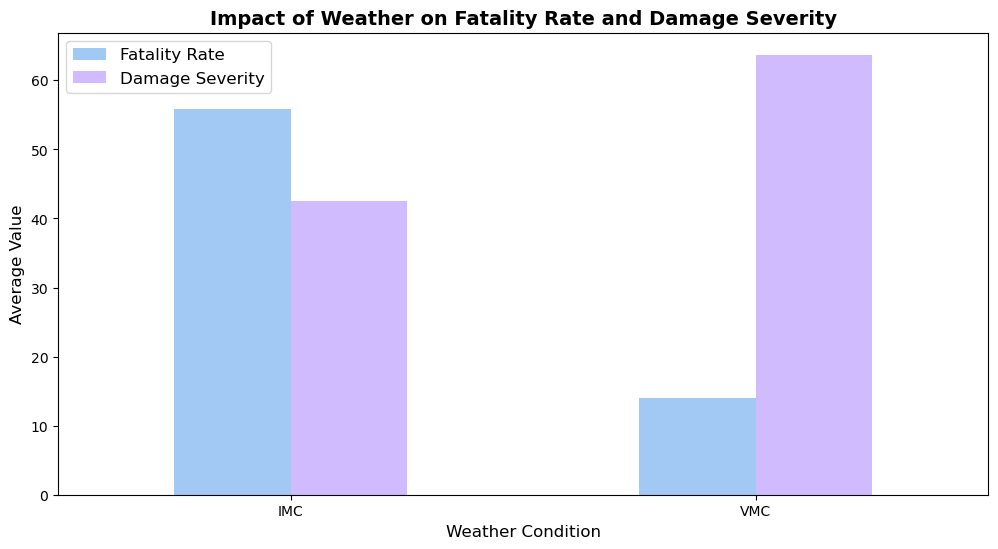

In [17]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

ava_wecond.groupby('Weather.Condition')[['Fatality.Rate', 'Damage.Severity']].mean().plot(kind='bar', figsize=(12, 6), color=['#a1c9f4', '#d0bbff'])

plt.title('Impact of Weather on Fatality Rate and Damage Severity', fontsize=14, fontweight='bold')
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Fatality Rate', 'Damage Severity'], fontsize=12)
plt.show()